<a href="https://colab.research.google.com/github/shivansh2310/Finance-Stuff/blob/main/us_kor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns

In [2]:
us_tech_tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META']
korean_tech_tickers = ['005930.KS', '000660.KS', '035420.KS', '035720.KS', '066570.KS']

all_tickers = us_tech_tickers + korean_tech_tickers

# Download data for the last 3 years
stock_data = yf.download(all_tickers, period='3y', auto_adjust=True)

print("Downloaded stock data:")
print(stock_data.head())

[*********************100%***********************]  10 of 10 completed

Downloaded stock data:
Price               Close                                             \
Ticker          000660.KS     005930.KS      035420.KS     035720.KS   
Date                                                                   
2023-07-31  120750.914062  66083.054688  222724.281250  51096.046875   
2023-08-01  122414.414062  67313.828125  228611.265625  54681.730469   
2023-08-02  116934.648438  66177.734375  223214.859375  52988.488281   
2023-08-03  117423.921875  65136.308594  218799.625000  53088.093750   
2023-08-04  117521.773438  64662.941406  219290.218750  51594.050781   

Price                                                                      \
Ticker          066570.KS        AAPL        AMZN       GOOGL        META   
Date                                                                        
2023-07-31  104906.515625  193.733994  133.679993  131.553497  315.826538   
2023-08-01  105680.726562  192.905624  131.690002  130.393768  319.900726   
2023-08-02  102

## Exploratory Data Analysis (EDA)

In [3]:
# Prepare data for plotting - focusing on 'Close' price
close_prices = stock_data['Close']

# Rename columns for better readability on plots
korean_stock_name_map = {
    '005930.KS': 'Samsung_Elec',
    '000660.KS': 'SK_Hynix',
    '035420.KS': 'Naver',
    '035720.KS': 'Kakao',
    '066570.KS': 'LG_Elec'
}
close_prices_renamed = close_prices.rename(columns=korean_stock_name_map)

print('Close Prices (renamed Korean tickers):')
display(close_prices_renamed.head())

Close Prices (renamed Korean tickers):


Ticker,SK_Hynix,Samsung_Elec,Naver,Kakao,LG_Elec,AAPL,AMZN,GOOGL,META,MSFT
Date,,,,,,,,,,
2023-07-31,120750.914062,66083.054688,222724.281250,51096.046875,104906.515625,193.733994,133.679993,131.553497,315.826538,328.155457
2023-08-01,122414.414062,67313.828125,228611.265625,54681.730469,105680.726562,192.905624,131.690002,130.393768,319.900726,328.565643
2023-08-02,116934.648438,66177.734375,223214.859375,52988.488281,102390.312500,189.917511,128.210007,127.251640,311.573853,319.929962
2023-08-03,117423.921875,65136.308594,218799.625000,53088.093750,101228.984375,188.526993,128.910004,127.321022,310.463715,319.109436
2023-08-04,117521.773438,64662.941406,219290.218750,51594.050781,100261.195312,179.473923,139.570007,126.984009,308.025085,320.203552


## Currency Normalization: Converting Korean Won (KRW) to US Dollar (USD)

To allow for a more direct comparison between US and Korean tech stocks, we need to convert the Korean stock prices from KRW to USD. This requires historical KRW/USD exchange rate data.

In [4]:
# Download historical KRW/USD exchange rate using yfinance
# 'KRW=X' is the ticker for KRW/USD exchange rate
krw_usd_exchange_rate = yf.download('KRW=X', period='3y', auto_adjust=True)['Close']

print('KRW/USD Exchange Rate (first 5 entries):')
display(krw_usd_exchange_rate.head())

[*********************100%***********************]  1 of 1 completed

KRW/USD Exchange Rate (first 5 entries):


Ticker,KRW=X
Date,
2023-07-31,1272.390015
2023-08-01,1277.930054
2023-08-02,1289.050049
2023-08-03,1295.369995
2023-08-04,1296.400024


In [5]:
# Create a DataFrame to hold all stock prices in USD
close_prices_usd = close_prices_renamed[us_tech_tickers].copy()

# Align exchange rate to stock data index (computed once, outside the loop)
# Use ffill() to handle missing exchange rates due to holidays/weekends
aligned_exchange_rate = krw_usd_exchange_rate['KRW=X'].reindex(close_prices_renamed.index).ffill()

# Convert Korean tech stock prices to USD
for ticker_original, ticker_renamed in korean_stock_name_map.items():
    if ticker_renamed in close_prices_renamed.columns:
        close_prices_usd[ticker_renamed] = close_prices_renamed[ticker_renamed] / aligned_exchange_rate

print('Close Prices (all in USD, first 5 entries):')
display(close_prices_usd.head())

Close Prices (all in USD, first 5 entries):


Ticker,AAPL,MSFT,GOOGL,AMZN,META,Samsung_Elec,SK_Hynix,Naver,Kakao,LG_Elec
Date,,,,,,,,,,
2023-07-31,193.733994,328.155457,131.553497,133.679993,315.826538,51.936163,94.900866,175.044034,40.157535,82.448396
2023-08-01,192.905624,328.565643,130.393768,131.690002,319.900726,52.674110,95.791169,178.891845,42.789298,82.696800
2023-08-02,189.917511,319.929962,127.251640,128.210007,311.573853,51.338375,90.713816,173.162291,41.106618,79.430828
2023-08-03,188.526993,319.109436,127.321022,128.910004,310.463715,50.283941,90.648944,168.908980,40.982958,78.146773
2023-08-04,179.473923,320.203552,126.984009,139.570007,308.025085,49.878849,90.652400,169.153205,39.797940,77.338162


Now that all stock prices are in a common currency (USD), we can perform more accurate comparative analysis and visualization.

### 1. Time Series Plot of All Stocks (USD Normalized)

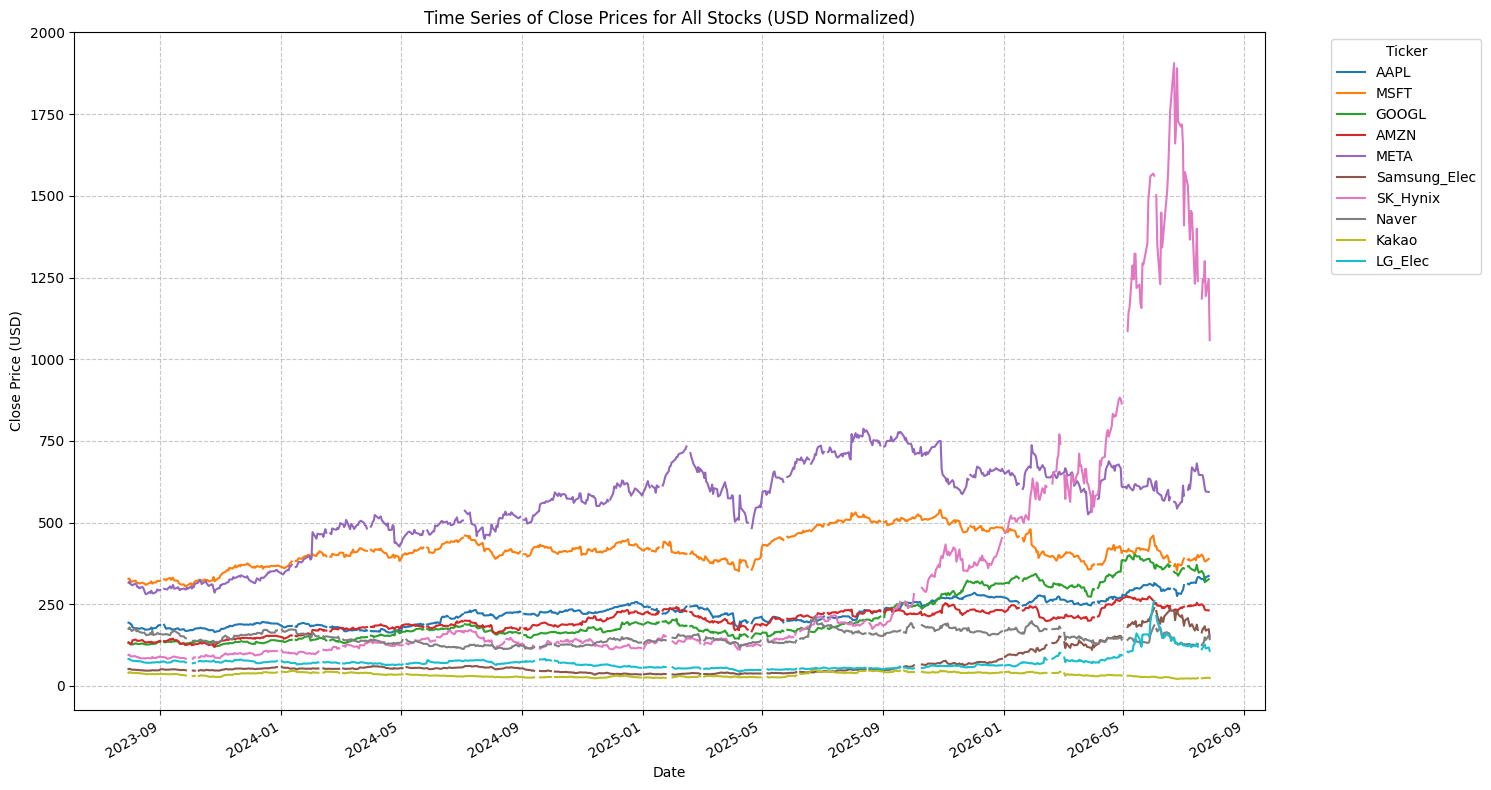

In [6]:
plt.figure(figsize=(15, 8))
close_prices_usd.plot(ax=plt.gca())
plt.title('Time Series of Close Prices for All Stocks (USD Normalized)')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Ticker', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 2. Time Series Plots for US and Korean Tech Stocks Separately (USD Normalized)

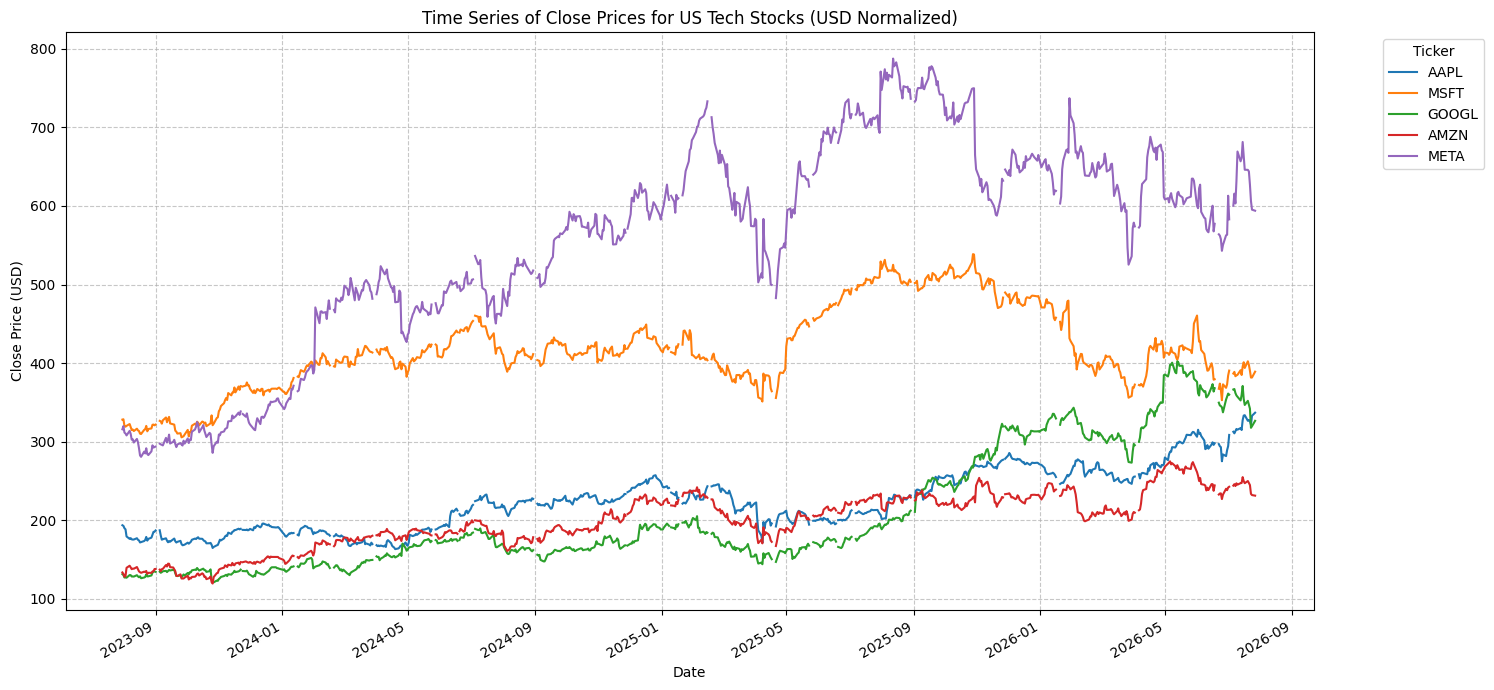

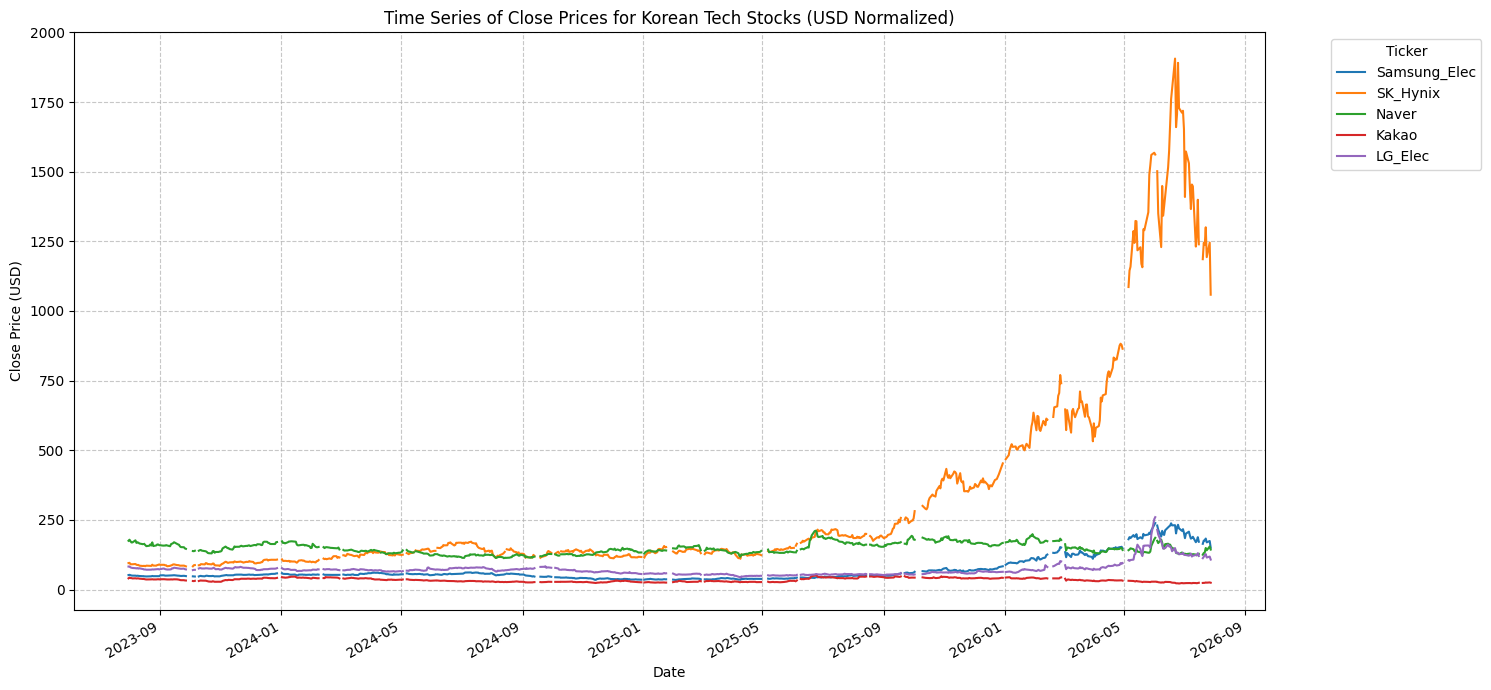

In [7]:
# Separate US and Korean stock data (now both in USD)
us_tech_data_usd = close_prices_usd[us_tech_tickers]
korean_tech_data_usd = close_prices_usd[list(korean_stock_name_map.values())]

plt.figure(figsize=(15, 7))
us_tech_data_usd.plot(ax=plt.gca())
plt.title('Time Series of Close Prices for US Tech Stocks (USD Normalized)')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Ticker', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 7))
korean_tech_data_usd.plot(ax=plt.gca())
plt.title('Time Series of Close Prices for Korean Tech Stocks (USD Normalized)')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Ticker', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 3. Statistical Analysis

In [8]:
print('Descriptive Statistics for All Stocks (USD Normalized):')
display(close_prices_usd.describe())

Descriptive Statistics for All Stocks (USD Normalized):


Ticker,AAPL,MSFT,GOOGL,AMZN,META,Samsung_Elec,SK_Hynix,Naver,Kakao,LG_Elec
count,751.000000,751.000000,751.000000,751.000000,751.000000,726.000000,726.000000,726.000000,726.000000,726.000000
mean,224.502100,417.263602,207.457337,198.871891,554.669569,70.121280,311.588036,147.938355,34.276230,72.224981
std,39.581763,52.804107,76.762320,35.722983,132.355680,45.698624,370.331274,19.656706,6.799181,24.081054
min,163.361420,305.570709,121.096207,119.570000,280.784271,34.198771,83.121855,112.460168,21.435777,42.924568
25%,189.782349,387.740387,153.345253,176.930000,482.136597,44.451762,120.356643,132.298339,27.872134,57.495316
50%,222.573975,411.739990,173.864014,201.699997,582.916382,52.863962,141.087687,145.206948,33.465641,69.565696
75%,253.939529,446.774368,263.180054,227.405006,652.461151,68.272012,356.099939,163.082760,40.361247,75.786403
max,340.440002,538.658569,402.379669,274.989990,787.419189,238.541091,1906.186180,211.081398,51.618643,259.715335


The descriptive statistics provide a summary of the central tendency, dispersion, and shape of the distribution of close prices for each stock. We can observe the mean, standard deviation (volatility), min, max, and quartile ranges. This gives us a preliminary understanding of each stock's behavior over the past three years.

Next, let's look at the distribution of prices using histograms and box plots, and then examine the correlations between these stocks.

### 4. Additional Plots: Histograms, Box Plots, and Correlation Heatmap

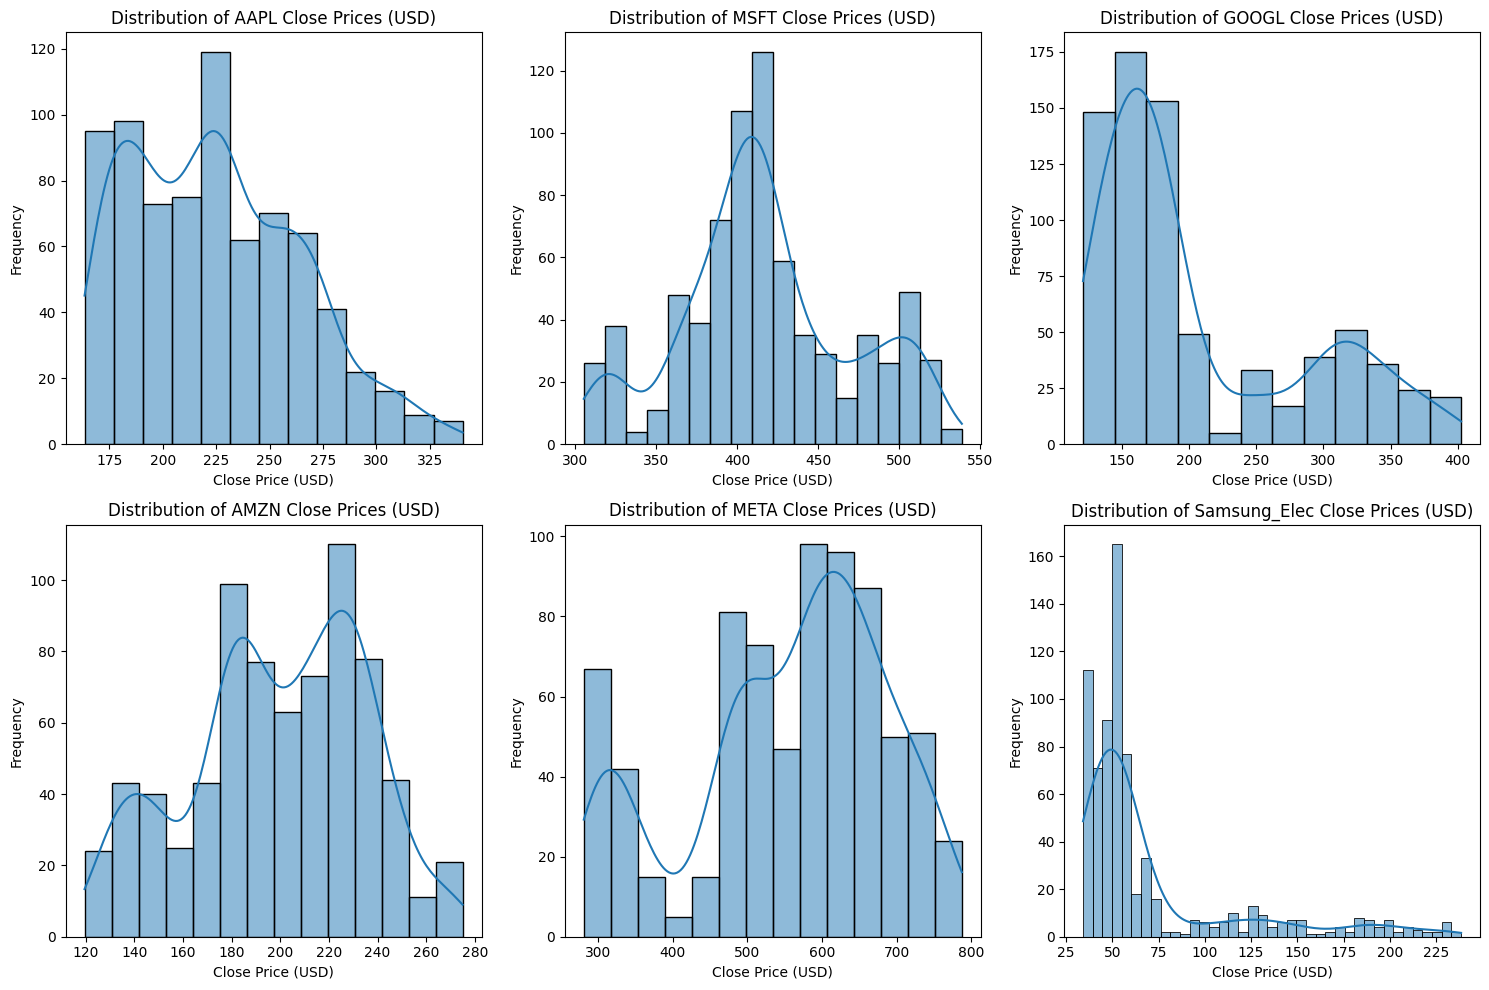

In [9]:
# Histograms for a sample of stocks
plt.figure(figsize=(15, 10))
for i, col in enumerate(close_prices_usd.columns[:6]): # Plotting first 6 stocks for better visualization
    plt.subplot(2, 3, i + 1)
    sns.histplot(close_prices_usd[col].dropna(), kde=True)
    plt.title(f'Distribution of {col} Close Prices (USD)')
    plt.xlabel('Close Price (USD)')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

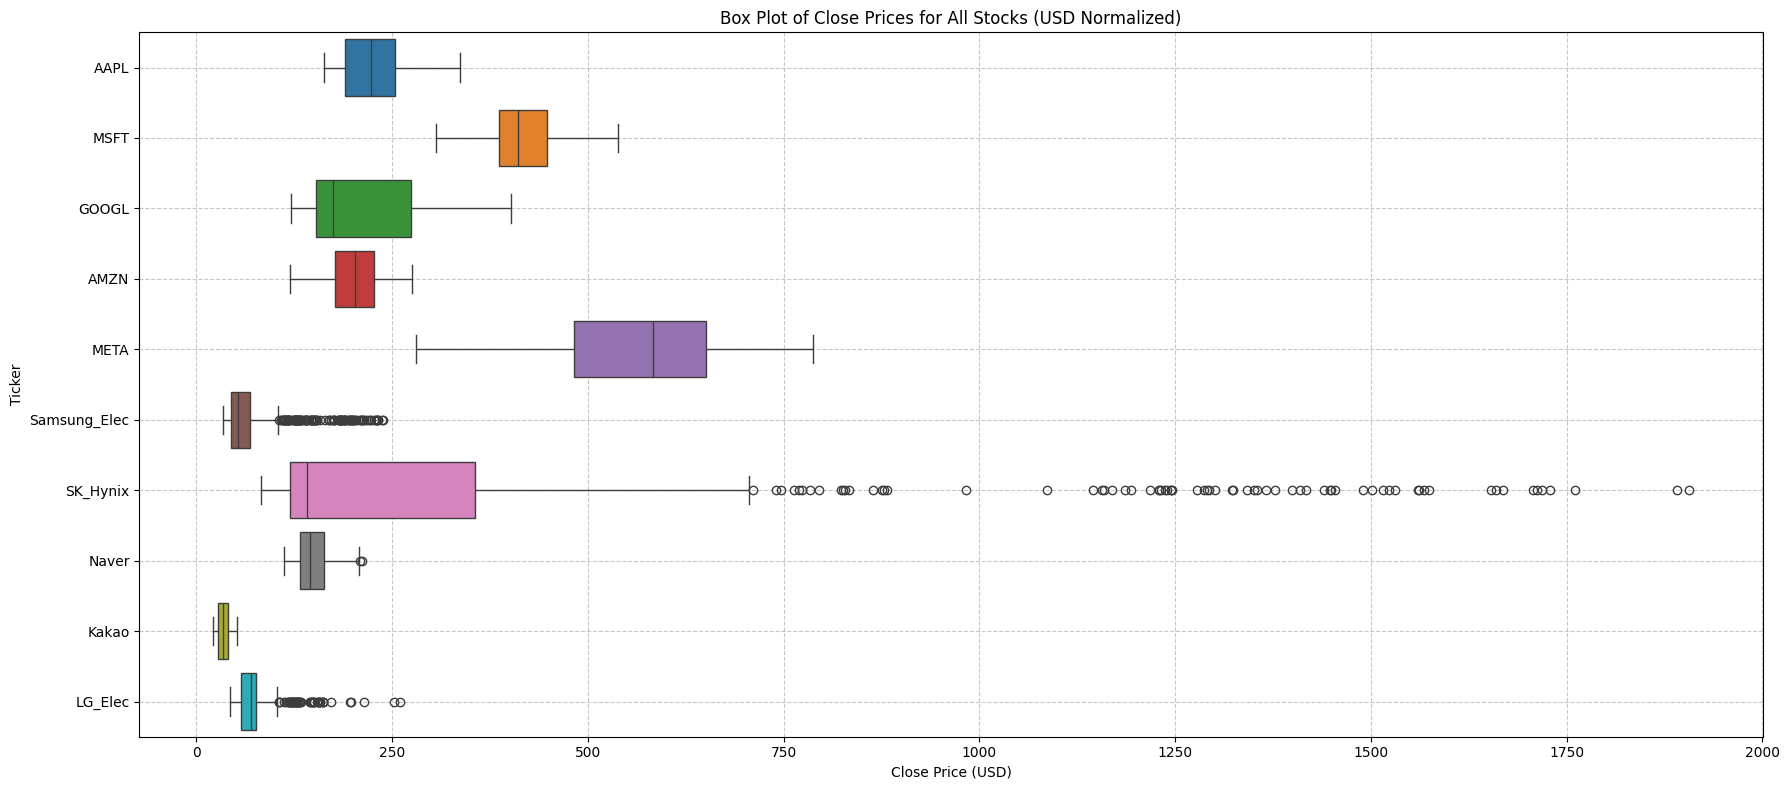

In [10]:
# Box Plots for all stocks
plt.figure(figsize=(18, 8))
sns.boxplot(data=close_prices_usd.dropna(), orient='h')
plt.title('Box Plot of Close Prices for All Stocks (USD Normalized)')
plt.xlabel('Close Price (USD)')
plt.ylabel('Ticker')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

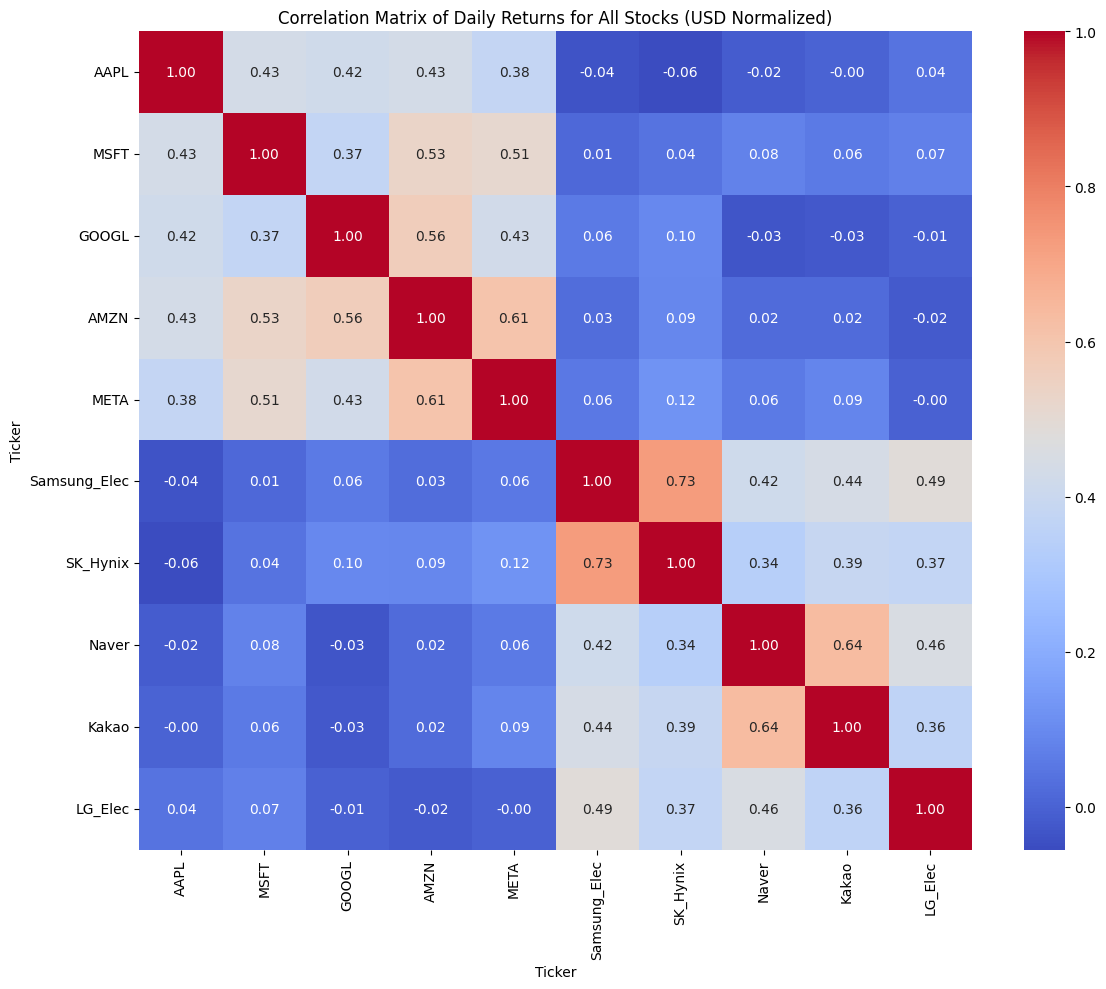

In [11]:
# Calculate daily returns to analyze volatility and correlation
daily_returns_usd = close_prices_usd.pct_change(fill_method=None).dropna()

# Correlation Heatmap of Daily Returns
plt.figure(figsize=(12, 10))
sns.heatmap(daily_returns_usd.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Daily Returns for All Stocks (USD Normalized)')
plt.tight_layout()
plt.show()

The correlation heatmap visualizes the linear relationships between the daily returns of different stocks. Values close to 1 indicate a strong positive correlation, values close to -1 indicate a strong negative correlation, and values close to 0 suggest no linear relationship. This can help identify diversification opportunities or co-moving assets within the portfolios.

Now, all the requested EDA steps, including time series plots, descriptive statistics, histograms, box plots, and a correlation heatmap, have been completed.

## Further Analysis: Correlation between US and Korean Stocks & Linear Regression

### 1. Correlation between US and Korean Stocks

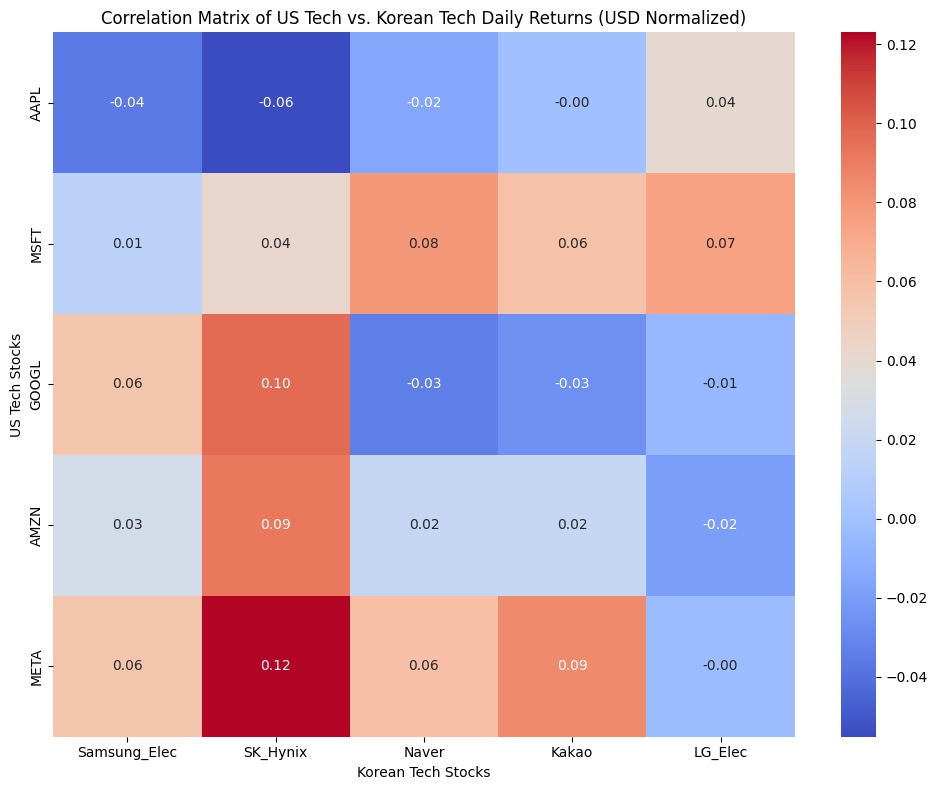


Cross-Market Correlation Matrix:


Ticker,Samsung_Elec,SK_Hynix,Naver,Kakao,LG_Elec
Ticker,,,,,
AAPL,-0.036007,-0.055139,-0.015319,-0.000166,0.039947
MSFT,0.013518,0.041922,0.078723,0.058153,0.074744
GOOGL,0.056184,0.096927,-0.034049,-0.025938,-0.005566
AMZN,0.026432,0.092211,0.019175,0.019232,-0.019229
META,0.055927,0.123033,0.059549,0.085429,-0.003212


In [12]:
# Separate US and Korean daily returns from the USD-normalized daily returns
us_returns_usd = daily_returns_usd[us_tech_tickers]
korean_returns_usd = daily_returns_usd[list(korean_stock_name_map.values())]

# Combine US and Korean returns for a single correlation matrix calculation
combined_returns = pd.concat([us_returns_usd, korean_returns_usd], axis=1)

# Calculate the full correlation matrix
full_correlation_matrix = combined_returns.corr(method='pearson')

# Extract the cross-market correlation block
cross_market_correlation = full_correlation_matrix.loc[us_returns_usd.columns, korean_returns_usd.columns]

plt.figure(figsize=(10, 8))
sns.heatmap(cross_market_correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of US Tech vs. Korean Tech Daily Returns (USD Normalized)')
plt.xlabel('Korean Tech Stocks')
plt.ylabel('US Tech Stocks')
plt.tight_layout()
plt.show()

print('\nCross-Market Correlation Matrix:')
display(cross_market_correlation)

This heatmap visualizes the correlation coefficients between the daily returns of each US tech stock and each Korean tech stock. Values closer to 1 indicate a strong positive linear relationship, while values closer to -1 indicate a strong negative linear relationship. Values near 0 suggest a weak or no linear relationship. This helps identify which markets and specific stocks tend to move together or in opposite directions.

### 2. Linear Regression: US Tech Stocks Explaining Korean Tech Stocks

In [13]:
import statsmodels.api as sm

# Independent variables (X): US tech stock daily returns
X = us_returns_usd.dropna()

print("Performing Linear Regression for each Korean Tech Stock against US Tech Stocks...")

# Dependent variable (Y): Each Korean tech stock's daily returns
for korean_ticker in korean_returns_usd.columns:
    Y = korean_returns_usd[korean_ticker].dropna()

    # Align X and Y based on common index (dates)
    common_index = X.index.intersection(Y.index)
    X_aligned = X.loc[common_index]
    Y_aligned = Y.loc[common_index]

    # Add a constant to the independent variables for the intercept term
    X_aligned = sm.add_constant(X_aligned)

    # Fit the OLS model
    model = sm.OLS(Y_aligned, X_aligned)
    results = model.fit()

    print(f'\n--- Regression Results for {korean_ticker} ---')
    print(results.summary())

Performing Linear Regression for each Korean Tech Stock against US Tech Stocks...

--- Regression Results for Samsung_Elec ---
                            OLS Regression Results                            
Dep. Variable:           Samsung_Elec   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.361
Date:                Wed, 29 Jul 2026   Prob (F-statistic):              0.237
Time:                        15:00:10   Log-Likelihood:                 1344.2
No. Observations:                 645   AIC:                            -2676.
Df Residuals:                     639   BIC:                            -2650.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----

These regression results show how well the daily returns of US tech stocks can explain the daily returns of each individual Korean tech stock. Key metrics to look at include:

*   **R-squared:** Indicates the proportion of the variance in the dependent variable (Korean stock returns) that can be predicted from the independent variables (US stock returns).
*   **Coefficients:** Show the change in the dependent variable for a one-unit change in the independent variable, holding other variables constant. A positive coefficient means they tend to move in the same direction, a negative coefficient means they tend to move in opposite directions.
*   **P-values:** For each coefficient, a low p-value (typically < 0.05) suggests that the coefficient is statistically significant and not due to random chance. The p-value for the F-statistic tests the overall significance of the regression model.